In [2]:
import pandas as pd

df = pd.read_excel("../Arquivos em Excel/ceagfgv.xls", index_col=0)

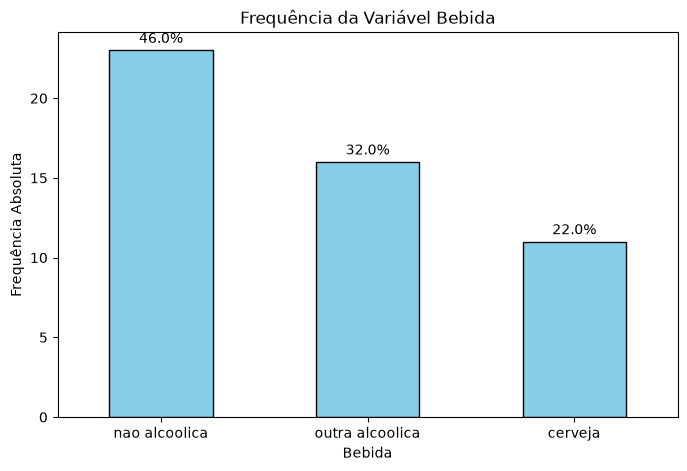

In [3]:
import matplotlib.pyplot as plt

freq_abs = df['bebida'].value_counts()
freq_rel = df['bebida'].value_counts(normalize=True) * 100

tabela_bebida = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Relativa (%)': freq_rel
})

# Adiciona a linha com a soma total das colunas
tabela_bebida.loc['Total'] = tabela_bebida.sum()

tabela_bebida

# Remove a linha de 'Total' para o gráfico
df_plot = tabela_bebida.drop('Total')

# Cria o gráfico de barras
ax = df_plot['Frequência Absoluta'].plot(kind='bar', figsize=(8, 5), color='skyblue', edgecolor='black')

# Adiciona a frequência relativa acima de cada barra
for i, (abs_val, rel_val) in enumerate(zip(df_plot['Frequência Absoluta'], df_plot['Frequência Relativa (%)'])):
    ax.annotate(f'{rel_val:.1f}%', 
                xy=(i, abs_val), 
                xytext=(0, 3), 
                textcoords="offset points", 
                ha='center', va='bottom')

plt.title('Frequência da Variável Bebida')
plt.xlabel('Bebida')
plt.ylabel('Frequência Absoluta')
plt.xticks(rotation=0)
plt.show()

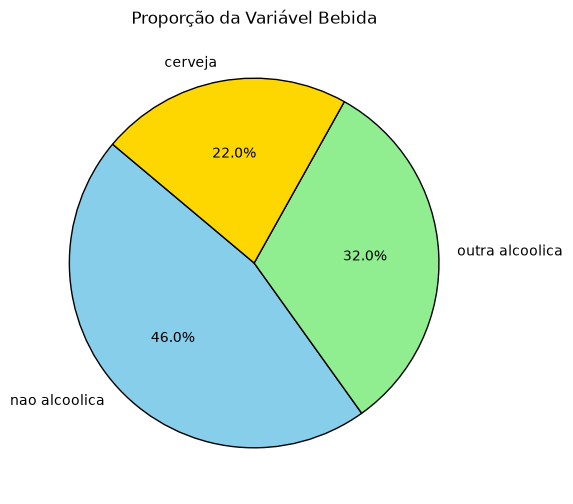

In [4]:
# Cria o gráfico de pizza
plt.figure(figsize=(6, 6))
plt.pie(df_plot['Frequência Absoluta'], 
    labels=df_plot.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['skyblue', 'lightgreen', 'gold'],
    wedgeprops={'edgecolor': 'black'})

plt.title('Proporção da Variável Bebida')
plt.show()

In [5]:
ordem_ingles = ['nenhum', 'algum', 'fluente']

freq_abs = df['ingles'].value_counts().reindex(ordem_ingles)
freq_rel = df['ingles'].value_counts(normalize=True).reindex(ordem_ingles) * 100

tabela_ingles = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Acumulada': freq_abs.cumsum(),
    'Frequência Relativa (%)': freq_rel,
    'Frequência Acumulada (%)': freq_rel.cumsum()
})

tabela_ingles

,Frequência Absoluta,Frequência Acumulada,Frequência Relativa (%),Frequência Acumulada (%)
ingles,,,,
nenhum,2,2,4.166667,4.166667
algum,26,28,54.166667,58.333333
fluente,20,48,41.666667,100.000000


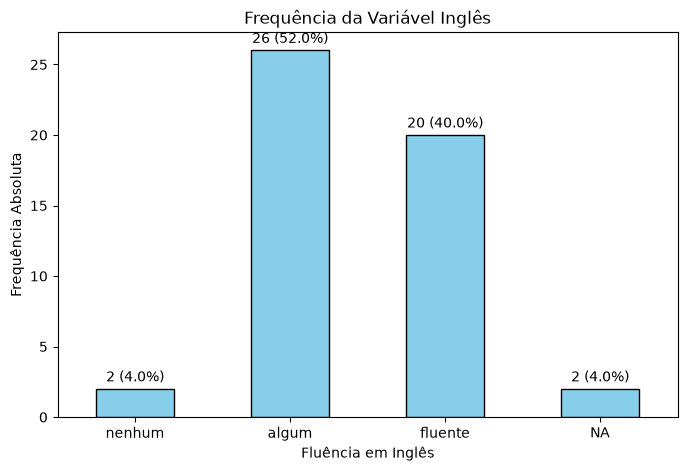

In [6]:
# Preenche os valores nulos da variável 'ingles' com 'NA'
df_ingles = df['ingles'].fillna('NA')
ordem_ingles_na = ['nenhum', 'algum', 'fluente', 'NA']

# Calcula frequências absoluta e relativa incluindo 'NA'
freq_abs_ingles = df_ingles.value_counts().reindex(ordem_ingles_na)
freq_rel_ingles = df_ingles.value_counts(normalize=True).reindex(ordem_ingles_na) * 100

# Cria o gráfico de barras
ax = freq_abs_ingles.plot(kind='bar', figsize=(8, 5), color='skyblue', edgecolor='black')

# Adiciona a frequência absoluta e relativa acima de cada barra
for i, (abs_val, rel_val) in enumerate(zip(freq_abs_ingles, freq_rel_ingles)):
    # Trata caso de valor nulo/NaN nos dados calculados
    abs_val_show = 0 if pd.isna(abs_val) else abs_val
    rel_val_show = 0.0 if pd.isna(rel_val) else rel_val
    
    ax.annotate(f'{abs_val_show:.0f} ({rel_val_show:.1f}%)', 
                xy=(i, abs_val_show), 
                xytext=(0, 3), 
                textcoords="offset points", 
                ha='center', va='bottom')

plt.title('Frequência da Variável Inglês')
plt.xlabel('Fluência em Inglês')
plt.ylabel('Frequência Absoluta')
plt.xticks(rotation=0)
plt.show()

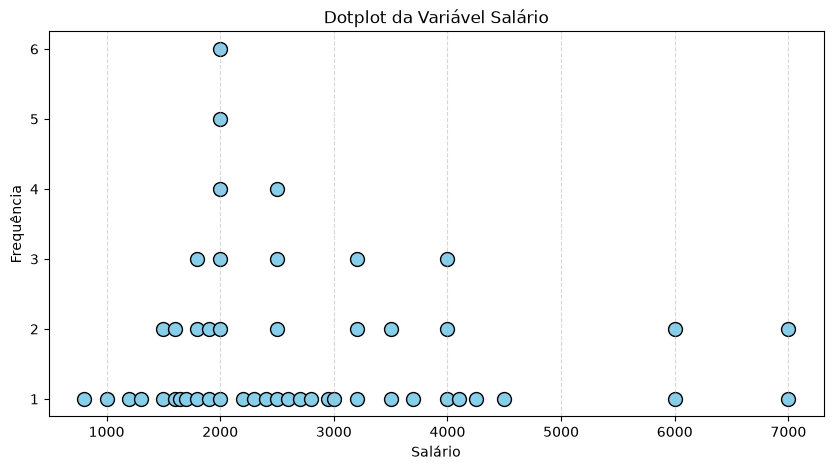

In [9]:
import numpy as np

# Remove valores nulos da variável 'salario'
salarios = df['salario'].dropna()

# Calcula as frequências para empilhar os pontos
valores, contagens = np.unique(salarios, return_counts=True)

x = []
y = []
for val, count in zip(valores, contagens):
    for i in range(count):
        x.append(val)
        y.append(i + 1)

# Cria o dotplot
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='skyblue', edgecolor='black', s=100)

plt.title('Dotplot da Variável Salário')
plt.xlabel('Salário')
plt.ylabel('Frequência')
plt.yticks(range(1, max(contagens) + 1))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()